In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    confusion_matrix
)


In [2]:
# 1. DATA LOADING & ROBUST CLEANING
df = pd.read_csv('netflix_titles.csv')

In [3]:
# Important columns only
df = df[['type', 'rating', 'country', 'date_added']]

In [4]:
# Data cleaning
df['date_added'] = pd.to_datetime(
    df['date_added'].astype(str).str.strip(),
    errors='coerce'
)

In [5]:
# Missing values handling
df.dropna(subset=['date_added', 'rating'], inplace=True)

In [6]:
# Year and month extraction
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month

In [7]:
# Primary country extraction
df['primary_country'] = (
    df['country']
    .fillna('Unknown')
    .apply(lambda x: x.split(',')[0].strip())
)

In [8]:
ml_df = df[
    ['rating', 'year_added', 'month_added', 'primary_country', 'type']
].copy()

In [9]:
# Target encoding only
target_encoder = LabelEncoder()

ml_df['type'] = target_encoder.fit_transform(ml_df['type'])

# One-hot encoding
ml_df = pd.get_dummies(
    ml_df,
    columns=['rating', 'primary_country'],
    drop_first=True
)

In [11]:
# Features & Target
X = ml_df.drop('type', axis=1)
y = ml_df['type']

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [14]:
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    random_state=42
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",12
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [16]:
y_pred = model.predict(X_test)

print("=" * 50)
print("MACHINE LEARNING MODEL RESULTS")
print("=" * 50)

accuracy = accuracy_score(y_test, y_pred)

print(f"\nModel Accuracy: {accuracy * 100:.2f}%\n")

print("Classification Report:\n")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=target_encoder.classes_
    )
)

MACHINE LEARNING MODEL RESULTS

Model Accuracy: 74.76%

Classification Report:

              precision    recall  f1-score   support

       Movie       0.75      0.97      0.84      1226
     TV Show       0.76      0.25      0.37       533

    accuracy                           0.75      1759
   macro avg       0.75      0.61      0.61      1759
weighted avg       0.75      0.75      0.70      1759



C:\Users\HP\AppData\Local\Temp\ipykernel_15144\3720292959.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


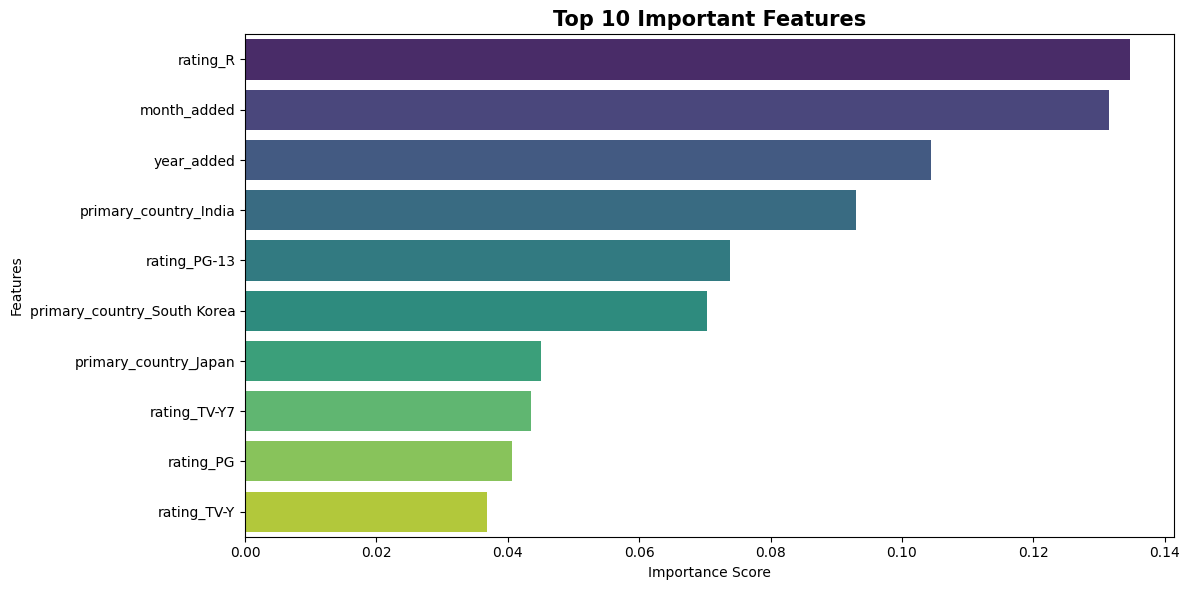

In [17]:
# Importance scores nikalna
importances = model.feature_importances_
# DataFrame banana
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
})
# Sort descending order me
feature_importance_df = feature_importance_df.sort_values(
    by='Importance',
    ascending=False
)
# Top 10 features
top_features = feature_importance_df.head(10)
# Plot
plt.figure(figsize=(12, 6))

sns.barplot(
    data=top_features,
    x='Importance',
    y='Feature',
    palette='viridis'
)
# Titles
plt.title(
    'Top 10 Important Features',
    fontsize=15,
    weight='bold'
)

plt.xlabel('Importance Score')
plt.ylabel('Features')

plt.tight_layout()
plt.show()

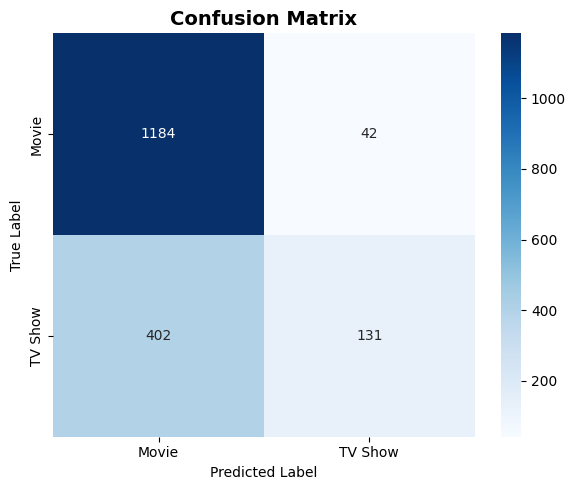

In [18]:
# Confusion matrix banana
cm = confusion_matrix(y_test, y_pred)

# Plot size
plt.figure(figsize=(6, 5))

# Heatmap
sns.heatmap(
    cm,
    annot=True,          # Boxes ke andar values show karega
    fmt='d',             # Integer format
    cmap='Blues',        # Blue color theme
    xticklabels=target_encoder.classes_,
    yticklabels=target_encoder.classes_
)

# Titles and labels
plt.title(
    'Confusion Matrix',
    fontsize=14,
    weight='bold'
)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')

# Layout fix
plt.tight_layout()

# Show plot
plt.show()